In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import sys
!{sys.executable} -m pip install mlflow -q

import mlflow
import mlflow.xgboost
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

# Load data
df = pd.read_csv('../data/processed/final_features.csv')
X = df.drop(columns=['stress_label', 'Credit_Score'])
y = df['stress_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Set up MLflow experiment
mlflow.set_experiment("sme-stress-predictor")

print("✅ MLflow set up")
print(f"MLflow version: {mlflow.__version__}")
print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

✅ MLflow set up
MLflow version: 3.15.0
Train size: (41068, 25)
Test size: (10268, 25)


In [3]:
# ── EXPERIMENT 1: LOGISTIC REGRESSION BASELINE ───────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

with mlflow.start_run(run_name="logistic_regression_baseline"):
    lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    lr.fit(X_train_scaled, y_train)

    lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
    lr_auc = roc_auc_score(y_test, lr_probs)
    lr_ap = average_precision_score(y_test, lr_probs)

    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("test_auc", lr_auc)
    mlflow.log_metric("test_ap", lr_ap)

    print(f"Logistic Regression — AUC: {lr_auc:.4f}, AP: {lr_ap:.4f}")

# ── EXPERIMENTS 2-6: XGBOOST WITH DIFFERENT CONFIGS ──────────────
configs = [
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.08},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05},
    {"n_estimators": 400, "max_depth": 6, "learning_rate": 0.03},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.7},
]

results = []
for i, config in enumerate(configs):
    run_name = f"xgboost_config_{i+1}"
    with mlflow.start_run(run_name=run_name):
        params = {
            "n_estimators": config["n_estimators"],
            "max_depth": config["max_depth"],
            "learning_rate": config["learning_rate"],
            "subsample": config.get("subsample", 0.8),
            "colsample_bytree": 0.8,
            "scale_pos_weight": y_train.value_counts()[0]/y_train.value_counts()[1],
            "eval_metric": "auc",
            "random_state": 42,
            "verbosity": 0
        }

        model = xgb.XGBClassifier(**params, early_stopping_rounds=20)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

        probs = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, probs)
        ap = average_precision_score(y_test, probs)

        # Precision at top decile
        sorted_idx = np.argsort(probs)[::-1]
        top10 = y_test.iloc[sorted_idx[:int(len(y_test)*0.1)]].mean()

        for k, v in params.items():
            mlflow.log_param(k, v)
        mlflow.log_metric("test_auc", auc)
        mlflow.log_metric("test_ap", ap)
        mlflow.log_metric("precision_top10", top10)

        results.append({"run": run_name, "auc": auc, "ap": ap, "precision_top10": top10})
        print(f"{run_name} — AUC: {auc:.4f}, AP: {ap:.4f}, P@10%: {top10:.1%}")

print("\n✅ 6 experiments logged to MLflow")

Logistic Regression — AUC: 0.7323, AP: 0.6436
xgboost_config_1 — AUC: 0.8028, AP: 0.7295, P@10%: 88.1%
xgboost_config_2 — AUC: 0.8173, AP: 0.7489, P@10%: 90.0%
xgboost_config_3 — AUC: 0.8219, AP: 0.7542, P@10%: 90.9%
xgboost_config_4 — AUC: 0.8250, AP: 0.7574, P@10%: 91.2%
xgboost_config_5 — AUC: 0.8211, AP: 0.7540, P@10%: 90.6%

✅ 6 experiments logged to MLflow


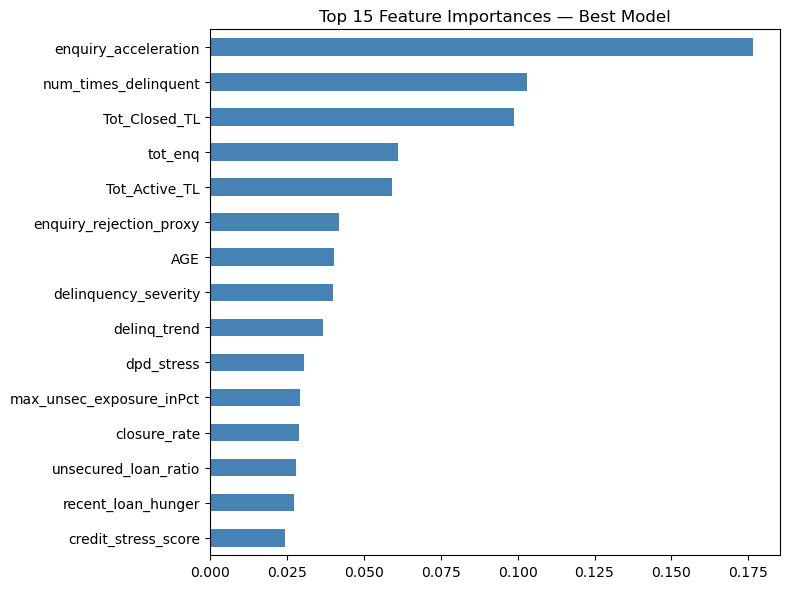


✅ Best model logged
Run ID: a8b0994fdf7b453ebe71f206a3b9f197
AUC: 0.8250 | Precision@5%: 96.3% | Precision@10%: 91.2%

✅ Model saved to /models/ for API deployment


In [4]:
# ── EXPERIMENT 7: BEST MODEL WITH FULL ARTIFACTS ─────────────────
best_params = {
    "n_estimators": 400,
    "max_depth": 6,
    "learning_rate": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": y_train.value_counts()[0]/y_train.value_counts()[1],
    "eval_metric": "auc",
    "random_state": 42,
    "verbosity": 0
}

with mlflow.start_run(run_name="best_model_final") as run:
    best_model = xgb.XGBClassifier(**best_params, early_stopping_rounds=20)
    best_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    probs = best_model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    ap = average_precision_score(y_test, probs)
    sorted_idx = np.argsort(probs)[::-1]
    top10 = y_test.iloc[sorted_idx[:int(len(y_test)*0.1)]].mean()
    top5 = y_test.iloc[sorted_idx[:int(len(y_test)*0.05)]].mean()

    for k, v in best_params.items():
        mlflow.log_param(k, v)
    mlflow.log_metric("test_auc", auc)
    mlflow.log_metric("test_ap", ap)
    mlflow.log_metric("precision_top10", top10)
    mlflow.log_metric("precision_top5", top5)

    # Log the actual model — this is what makes it production-ready
    mlflow.xgboost.log_model(best_model, name="model")

    # Log feature importance as an artifact
    import matplotlib.pyplot as plt
    importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
    importance = importance.sort_values(ascending=True).tail(15)
    plt.figure(figsize=(8, 6))
    importance.plot(kind='barh', color='steelblue')
    plt.title('Top 15 Feature Importances — Best Model')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    mlflow.log_artifact('feature_importance.png')
    plt.show()

    run_id = run.info.run_id
    print(f"\n✅ Best model logged")
    print(f"Run ID: {run_id}")
    print(f"AUC: {auc:.4f} | Precision@5%: {top5:.1%} | Precision@10%: {top10:.1%}")

# Save best model locally too, for the FastAPI step later
import joblib
joblib.dump(best_model, '../models/best_xgboost_model.pkl')
joblib.dump(list(X_train.columns), '../models/feature_names.pkl')
print("\n✅ Model saved to /models/ for API deployment")